In [1]:
%pip install optuna xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
train_data = pd.read_csv(
    "train_fraud_balanced.csv"
)

validation_data = pd.read_csv(
    "validation_fraud.csv"
)

print("Training dataset:", train_data.shape)
print("Validation dataset:", validation_data.shape)

Training dataset: (79328, 45)
Validation dataset: (8648, 45)


In [4]:
if "is_fraud" not in train_data.columns:
    raise ValueError(
        "is_fraud column is missing from training data."
    )

if "is_fraud" not in validation_data.columns:
    raise ValueError(
        "is_fraud column is missing from validation data."
    )

print("Target columns found successfully!")

Target columns found successfully!


In [5]:
X_train = train_data.drop(
    columns=["is_fraud"]
)

y_train = train_data["is_fraud"]

X_validation = validation_data.drop(
    columns=["is_fraud"]
)

y_validation = validation_data["is_fraud"]

In [6]:
common_columns = [
    column for column in X_train.columns
    if column in X_validation.columns
]

if len(common_columns) == 0:
    raise ValueError(
        "No common feature columns found."
    )

X_train = X_train[common_columns].copy()
X_validation = X_validation[common_columns].copy()

print("Common features:", len(common_columns))

Common features: 44


In [7]:
for column in common_columns:

    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce"
    )

    X_validation[column] = pd.to_numeric(
        X_validation[column],
        errors="coerce"
    )

In [8]:
usable_columns = [
    column for column in X_train.columns
    if X_train[column].notna().any()
]

if len(usable_columns) == 0:
    raise ValueError(
        "No usable numeric features were found."
    )

X_train = X_train[usable_columns].copy()
X_validation = X_validation[usable_columns].copy()

print("Usable numeric features:", len(usable_columns))

Usable numeric features: 22


In [9]:
y_train = pd.to_numeric(
    y_train,
    errors="coerce"
)

y_validation = pd.to_numeric(
    y_validation,
    errors="coerce"
)

valid_train_rows = y_train.notna()
valid_validation_rows = y_validation.notna()

X_train = X_train.loc[
    valid_train_rows
].reset_index(drop=True)

y_train = y_train.loc[
    valid_train_rows
].astype(int).reset_index(drop=True)

X_validation = X_validation.loc[
    valid_validation_rows
].reset_index(drop=True)

y_validation = y_validation.loc[
    valid_validation_rows
].astype(int).reset_index(drop=True)

print("Training classes:")
print(y_train.value_counts())

print("\nValidation classes:")
print(y_validation.value_counts())

Training classes:
is_fraud
0    39664
1    39664
Name: count, dtype: int64

Validation classes:
is_fraud
0    8499
1     149
Name: count, dtype: int64


In [10]:
training_medians = X_train.median()

X_train = X_train.fillna(
    training_medians
)

X_validation = X_validation.fillna(
    training_medians
)

X_train = X_train.fillna(0)
X_validation = X_validation.fillna(0)

print(
    "Training missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Validation missing values:",
    X_validation.isnull().sum().sum()
)

Training missing values: 0
Validation missing values: 0


In [11]:
def objective(trial):

    parameters = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            50,
            250
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0.0,
            5.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0.0,
            2.0
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.5,
            5.0
        )
    }

    model = XGBClassifier(
        **parameters,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=1
    )

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    predictions = model.predict(
        X_validation
    )

    score = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    return score

In [12]:
sampler = optuna.samplers.TPESampler(
    seed=42
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="xgboost_fraud_optimization"
)

print("Optuna study created successfully!")

[I 2026-08-12 19:35:49,660] A new study created in memory with name: xgboost_fraud_optimization


Optuna study created successfully!


In [13]:
study.optimize(
    objective,
    n_trials=15,
    show_progress_bar=True
)

print("Hyperparameter optimization completed!")

  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-08-12 19:36:05,393] Trial 0 finished with value: 0.09009009009009009 and parameters: {'n_estimators': 125, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 3.20501755284444}. Best is trial 0 with value: 0.09009009009009009.
[I 2026-08-12 19:36:07,322] Trial 1 finished with value: 0.07080745341614907 and parameters: {'n_estimators': 192, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 2.86140394234507}. Best is trial 0 with value: 0.09009009009009009.
[I 2026-08-12 19:36:08,989] Trial 2 finished with value: 0.08677098150782361 and parameters: {'n_estimators': 136, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0

In [14]:
print("Best validation F1 score:")
print(round(study.best_value, 4))

print("\nBest hyperparameters:")

for parameter, value in study.best_params.items():
    print(parameter, ":", value)

Best validation F1 score:
0.1001

Best hyperparameters:
n_estimators : 170
max_depth : 10
learning_rate : 0.01351182947645082
subsample : 0.6783931449676581
colsample_bytree : 0.6180909155642152
min_child_weight : 4
gamma : 1.9433864484474102
reg_alpha : 0.5426980635477918
reg_lambda : 4.229318791183682


In [15]:
best_parameters = study.best_params.copy()

best_xgb_model = XGBClassifier(
    **best_parameters,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1
)

print("Best XGBoost model created!")

Best XGBoost model created!


In [16]:
best_xgb_model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_validation, y_validation)
    ],
    verbose=False
)

print("Best XGBoost model trained successfully!")

Best XGBoost model trained successfully!


In [17]:
optimized_predictions = best_xgb_model.predict(
    X_validation
)

optimized_probabilities = best_xgb_model.predict_proba(
    X_validation
)[:, 1]

print("Optimized predictions created!")

Optimized predictions created!


In [18]:
optimized_accuracy = accuracy_score(
    y_validation,
    optimized_predictions
)

optimized_precision = precision_score(
    y_validation,
    optimized_predictions,
    zero_division=0
)

optimized_recall = recall_score(
    y_validation,
    optimized_predictions,
    zero_division=0
)

optimized_f1 = f1_score(
    y_validation,
    optimized_predictions,
    zero_division=0
)

optimized_roc_auc = roc_auc_score(
    y_validation,
    optimized_probabilities
)

print("OPTIMIZED XGBOOST RESULTS")
print("--------------------------")
print("Accuracy:", round(optimized_accuracy, 4))
print("Precision:", round(optimized_precision, 4))
print("Recall:", round(optimized_recall, 4))
print("F1 Score:", round(optimized_f1, 4))
print("ROC-AUC:", round(optimized_roc_auc, 4))

OPTIMIZED XGBOOST RESULTS
--------------------------
Accuracy: 0.9085
Precision: 0.0603
Recall: 0.2953
F1 Score: 0.1001
ROC-AUC: 0.6272


In [19]:
print(
    classification_report(
        y_validation,
        optimized_predictions,
        labels=[0, 1],
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.99      0.92      0.95      8499
       Fraud       0.06      0.30      0.10       149

    accuracy                           0.91      8648
   macro avg       0.52      0.61      0.53      8648
weighted avg       0.97      0.91      0.94      8648



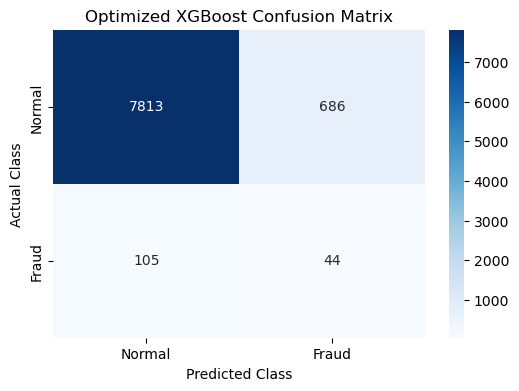

In [20]:
optimized_confusion = confusion_matrix(
    y_validation,
    optimized_predictions,
    labels=[0, 1]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    optimized_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Optimized XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [21]:
trials_table = study.trials_dataframe()

trials_table[[
    "number",
    "value",
    "state"
]].head(15)

,number,value,state
0,0,0.090090,COMPLETE
1,1,0.070807,COMPLETE
2,2,0.086771,COMPLETE
3,3,0.095722,COMPLETE
4,4,0.078670,COMPLETE
5,5,0.083389,COMPLETE
6,6,0.100114,COMPLETE
7,7,0.080528,COMPLETE
8,8,0.081349,COMPLETE
9,9,0.084352,COMPLETE


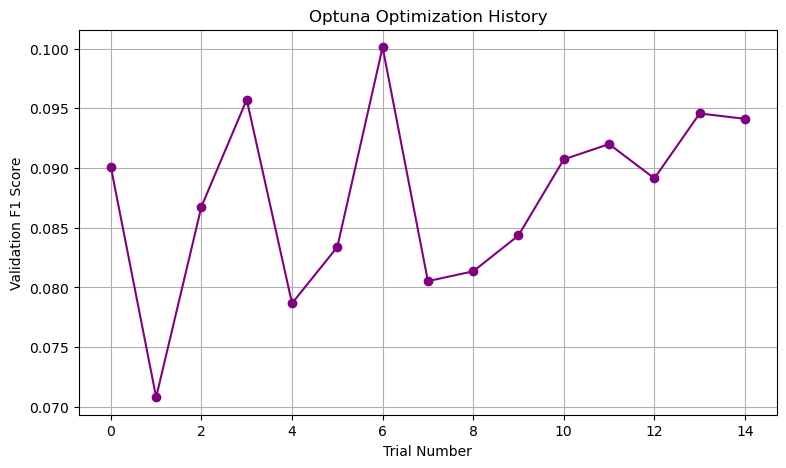

In [22]:
completed_trials = trials_table[
    trials_table["state"] == "COMPLETE"
].copy()

plt.figure(figsize=(9, 5))

plt.plot(
    completed_trials["number"],
    completed_trials["value"],
    marker="o",
    color="purple"
)

plt.title("Optuna Optimization History")
plt.xlabel("Trial Number")
plt.ylabel("Validation F1 Score")
plt.grid(True)
plt.show()

In [23]:
optimized_results = pd.DataFrame({
    "model": ["Optimized XGBoost"],
    "accuracy": [optimized_accuracy],
    "precision": [optimized_precision],
    "recall": [optimized_recall],
    "f1_score": [optimized_f1],
    "roc_auc": [optimized_roc_auc]
})

optimized_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Optimized XGBoost,0.9085,0.0603,0.2953,0.1001,0.6272


In [24]:
optimized_results.to_csv(
    "optimized_xgboost_results.csv",
    index=False
)

trials_table.to_csv(
    "optuna_xgboost_trials.csv",
    index=False
)

print("Optimization results saved successfully!")

Optimization results saved successfully!


In [25]:
with open(
    "best_xgboost_parameters.json",
    "w"
) as file:

    json.dump(
        best_parameters,
        file,
        indent=4
    )

print("Best parameters saved successfully!")

Best parameters saved successfully!


In [26]:
best_xgb_model.save_model(
    "optimized_xgboost_fraud_model.json"
)

print("Optimized XGBoost model saved successfully!")

Optimized XGBoost model saved successfully!
